# Train scVI model

In [1]:
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


## Set paths, import data

In [3]:
# Directories
base_dir = Path("/home/workspace/private/projects/kim/drg")
data_dir = base_dir / "data" / "scrna-seq"
input_dir = data_dir

h5ad_dir = data_dir / "h5ad" / "03_scvi"
model_dir = data_dir / "scvi_A"

h5ad_dir.mkdir(parents=True, exist_ok=True)

# File
h5ad_out = h5ad_dir / "GSE139088-scvi.h5ad"

In [4]:
adata_path = input_dir / "GSE139088-clean.h5ad"
#adata_path = input_dir / "GSE254789-clean.h5ad"

In [5]:
adata = sc.read_h5ad(adata_path)
#adata = sc.read_h5ad(adata_path)

In [6]:
adata.obs.sample_id.value_counts()

sample_id
GSE139088_3    2634
GSE139088_5    2576
GSE139088_4    2026
GSE139088_2    1456
GSE139088_1    1384
GSE139088_6     724
Name: count, dtype: int64

## Prepare adata

In [7]:
adata.X[:5, :5]

array([[0.        , 6.35977679, 0.        , 0.        , 5.66835787],
       [4.61546711, 4.61546711, 3.93216883, 3.93216883, 4.61546711],
       [0.        , 4.98765456, 4.30130586, 0.        , 0.        ],
       [5.10892117, 4.02232163, 0.        , 0.        , 4.7064728 ],
       [4.58566652, 4.98772686, 0.        , 0.        , 5.27370219]])

In [8]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers["counts"].copy()

print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: False
adata.X has only whole numbers: True


In [9]:
adata.X[:5, :5]

array([[0., 4., 0., 0., 2.],
       [2., 2., 1., 1., 2.],
       [0., 2., 1., 0., 0.],
       [3., 1., 0., 0., 2.],
       [2., 3., 0., 0., 4.]])

## scVI

#### Train model

In [10]:
# Set up AnnData for SCVI
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts",  # Use raw count data
    batch_key = 'sample_id'
)

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [11]:
# Initialize model
model = scvi.model.SCVI(
    adata
)

In [12]:
# Train SCVI model
model.train(
    early_stopping=True,
    accelerator = "gpu",
    enable_progress_bar=True
)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a

Epoch 270/400:  68%|██████▊   | 270/400 [13:08<06:19,  2.92s/it, v_num=1, train_loss_step=1.03e+4, train_loss_epoch=1.03e+4]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 10376.028. Signaling Trainer to stop.


In [13]:
model.save(model_dir, prefix='20250612A_')

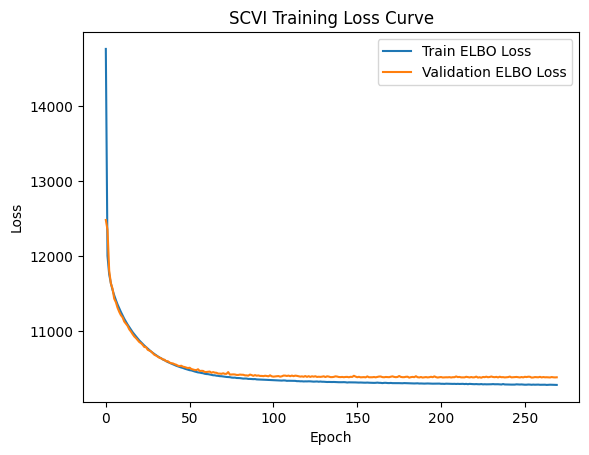

In [14]:
plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("SCVI Training Loss Curve")
plt.show()

## Extract latent representation, save

In [15]:
# add scVI latent dimensions to adata.obsm
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)
adata.obsm['X_scVI'].shape

(10800, 10)

## Export

In [16]:
adata.write_h5ad(h5ad_out, compression='gzip')

## Session info

In [18]:
import os
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
